# EXPERIMENT NO. 8
## Application of Optical Flow for Real-Time Object Tracking and Motion Analysis

**Name:** Abhigyan Dubey
**CUID:** CU24250059
**Course:** B.Tech CSE
**Section:** CSE "B"
**Roll No.:** 02

**Aim:** To implement an optical flow-based motion analysis system for object tracking and evaluate how effectively it tracks moving objects in video using Python and OpenCV.

### Step 1: Import libraries and load video, read frames
Frames are downscaled (avoids Colab crashes with 4K video). `cv2.imshow` does not work in Colab, so results are shown with Matplotlib.

In [1]:
import cv2, time
import numpy as np
import matplotlib.pyplot as plt

try:                                   # Google Colab: upload from computer
    from google.colab import files
    up = files.upload(); video_filename = next(iter(up))
except ImportError:                    # Local Jupyter / VS Code
    video_filename = "video.mp4"

cap = cv2.VideoCapture(video_filename)
if not cap.isOpened(): raise RuntimeError("Could not open video file.")
fps = cap.get(cv2.CAP_PROP_FPS) or 30
for _ in range(5): cap.read()                       # skip fade-in frames
frames = []
while len(frames) < 60:                             # use first 60 frames
    ok, f = cap.read()
    if not ok: break
    h, w = f.shape[:2]
    frames.append(cv2.resize(f, (640, int(h*640/w)), interpolation=cv2.INTER_AREA) if w > 640 else f)
cap.release()
if len(frames) < 15: raise RuntimeError("Video too short (need at least 20 frames).")
gray = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in frames]
print(f"{len(frames)} frames, {frames[0].shape[1]}x{frames[0].shape[0]}, {fps:.1f} fps")

Saving wanderer-genshin-impact.1920x1080.mp4 to wanderer-genshin-impact.1920x1080.mp4
60 frames, 640x360, 30.0 fps


### Steps 2-5: Shi-Tomasi corners + Lucas-Kanade tracking
Shi-Tomasi selects strong corners in frame 0; Lucas-Kanade then tracks them frame by frame, recording trajectories, displacement, direction and speed.

In [2]:
lk = dict(winSize=(15, 15), maxLevel=2,
          criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
p0 = cv2.goodFeaturesToTrack(gray[0], maxCorners=50, qualityLevel=0.3, minDistance=10, blockSize=7)
N = len(p0)

def track_lk(gray):
    p, alive = p0.copy(), np.ones(N, bool)
    traj, speed, alive_cnt = [p.reshape(-1, 2).copy()], [], [N]
    t = time.perf_counter()
    for i in range(1, len(gray)):
        p1, st, _ = cv2.calcOpticalFlowPyrLK(gray[i-1], gray[i], p, None, **lk)
        alive &= st.ravel() == 1
        d = (p1 - p).reshape(-1, 2)[alive]
        speed.append(np.linalg.norm(d, axis=1).mean() if alive.any() else 0)   # px/frame
        p = p1; traj.append(p.reshape(-1, 2).copy()); alive_cnt.append(alive.sum())
    return np.array(traj), alive, np.array(speed), alive_cnt, (time.perf_counter()-t)/(len(gray)-1)*1000

traj_lk, alive_lk, speed_lk, alive_cnt, ms_lk = track_lk(gray)

def draw_traj(img, traj, alive):
    out = img.copy()
    for k in np.where(alive)[0]:
        cv2.polylines(out, [traj[:, k].astype(np.int32)], False, (0, 255, 0), 2)
        cv2.arrowedLine(out, tuple(traj[0, k].astype(int)), tuple(traj[-1, k].astype(int)), (0, 0, 255), 2, tipLength=0.2)
        cv2.circle(out, tuple(traj[-1, k].astype(int)), 4, (255, 0, 0), -1)
    return out

# Direction and magnitude of overall motion (tracked points still alive)
disp = traj_lk[-1][alive_lk] - traj_lk[0][alive_lk]
mean_disp = disp.mean(axis=0)
print(f"Points still tracked: {alive_lk.sum()}/{N}")
print(f"Mean displacement: {np.linalg.norm(mean_disp):.1f} px, direction: {np.degrees(np.arctan2(-mean_disp[1], mean_disp[0])):.0f} deg")
print(f"Average speed: {speed_lk.mean():.2f} px/frame = {speed_lk.mean()*fps:.1f} px/s")

Points still tracked: 35/35
Mean displacement: 0.9 px, direction: -79 deg
Average speed: 0.04 px/frame = 1.1 px/s


### Step 6: Farneback dense optical flow tracking
The same starting points are moved frame by frame using the dense flow value at their position, so both methods can be compared directly.

Lucas-Kanade: 1.0 ms/frame | Farneback: 78.9 ms/frame
Avg speed  LK: 0.04 px/frame | FB: 0.04 px/frame
Mean end-point difference between LK and Farneback tracks: 0.1 px


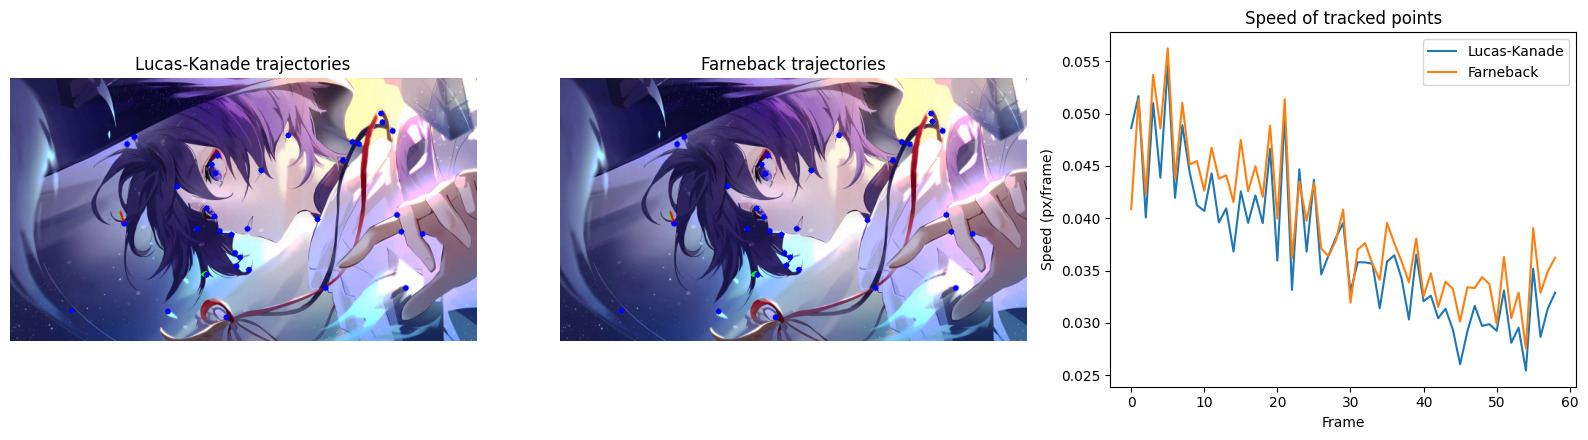

In [3]:
def track_fb(gray):
    pos = p0.reshape(-1, 2).copy(); traj, speed = [pos.copy()], []
    t = time.perf_counter()
    for i in range(1, len(gray)):
        fl = cv2.calcOpticalFlowFarneback(gray[i-1], gray[i], None, 0.5, 3, 15, 3, 5, 1.2, 0)
        H, W = gray[i].shape
        xi = np.clip(pos[:, 0].round().astype(int), 0, W-1); yi = np.clip(pos[:, 1].round().astype(int), 0, H-1)
        d = fl[yi, xi]; pos = pos + d
        speed.append(np.linalg.norm(d, axis=1).mean()); traj.append(pos.copy())
    return np.array(traj), np.array(speed), (time.perf_counter()-t)/(len(gray)-1)*1000

traj_fb, speed_fb, ms_fb = track_fb(gray)
err = np.linalg.norm(traj_fb[-1][alive_lk] - traj_lk[-1][alive_lk], axis=1).mean() if alive_lk.any() else float("nan")
print(f"Lucas-Kanade: {ms_lk:.1f} ms/frame | Farneback: {ms_fb:.1f} ms/frame")
print(f"Avg speed  LK: {speed_lk.mean():.2f} px/frame | FB: {speed_fb.mean():.2f} px/frame")
print(f"Mean end-point difference between LK and Farneback tracks: {err:.1f} px")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].imshow(cv2.cvtColor(draw_traj(frames[-1], traj_lk, alive_lk), cv2.COLOR_BGR2RGB)); ax[0].set_title("Lucas-Kanade trajectories")
ax[1].imshow(cv2.cvtColor(draw_traj(frames[-1], traj_fb, np.ones(N, bool)), cv2.COLOR_BGR2RGB)); ax[1].set_title("Farneback trajectories")
ax[0].axis("off"); ax[1].axis("off")
ax[2].plot(speed_lk, label="Lucas-Kanade"); ax[2].plot(speed_fb, label="Farneback")
ax[2].set_xlabel("Frame"); ax[2].set_ylabel("Speed (px/frame)"); ax[2].set_title("Speed of tracked points"); ax[2].legend()
plt.tight_layout(); plt.show()

### Step 7: Effect of speed, illumination, occlusion and camera movement
Lucas-Kanade is re-run on modified frame pairs. *Survival* = percentage of Shi-Tomasi points that are still tracked.

In [4]:
def survival(g1, g2):
    p1, st, _ = cv2.calcOpticalFlowPyrLK(g1, g2, p0, None, **lk)
    ok = st.ravel() == 1
    return 100*ok.mean(), (np.linalg.norm((p1-p0).reshape(-1, 2)[ok], axis=1).mean() if ok.any() else 0)

occ = gray[1].copy(); occ[:, int(np.median(p0[:, 0, 0])):] = 0          # hide half of the tracked points
shift = np.float32([[1, 0, 8], [0, 1, 4]])
tests = {
    "Normal (frame 0 -> 1)":        gray[1],
    "Fast object (frame 0 -> 10)":  gray[10],
    "Illumination drop (50%)":      cv2.convertScaleAbs(gray[1], alpha=0.5),
    "Occlusion (half the points)":       occ,
    "Camera motion (8,4 px pan)":   cv2.warpAffine(gray[1], shift, gray[1].shape[::-1]),
}
print(f"{'Scenario':30s}{'Survival %':>12s}{'Mean disp (px)':>16s}")
for k, g in tests.items():
    s, d = survival(gray[0], g); print(f"{k:30s}{s:12.0f}{d:16.2f}")

Scenario                        Survival %  Mean disp (px)
Normal (frame 0 -> 1)                  100            0.05
Fast object (frame 0 -> 10)            100            0.45
Illumination drop (50%)                 97           61.76
Occlusion (half the points)             77           67.75
Camera motion (8,4 px pan)             100            8.93


### Steps 8-10: Analysis and Observations

**Parameters from the tracked motion:** displacement, direction and average speed are printed above. Trajectories show the path of each point; the speed plot shows how motion changes over time.

**Lucas-Kanade vs Farneback:** Lucas-Kanade is faster (few points) and follows chosen corners well, but points are lost when they leave the frame, are occluded or move too fast. Farneback always gives a flow value at every pixel so tracks never "disappear", but it is slower, and errors accumulate when points are moved frame after frame (drift).

**Effect of conditions (see table):** fast motion, illumination changes, occlusion and camera pans reduce the survival percentage or add wrong motion, because they break the brightness-constancy and small-motion assumptions. A camera pan also adds background motion to every point.

**Optical flow vs frame-by-frame detection:** flow tracking is lightweight, keeps an object's identity across frames and needs no trained model, but it drifts and cannot recognise what the object is. Detection (e.g., YOLO) identifies objects and recovers after loss, but is heavier and gives no motion information by itself. A practical system detects periodically and tracks with optical flow in between.

**Applications:** traffic monitoring, surveillance, robotics navigation, sports analytics and gesture/activity recognition.

## Viva Questions

**Q1. Tracking vs detection?** Detection finds and classifies objects in each frame independently. Tracking follows an object over time and keeps its identity, using motion information from previous frames.

**Q2. Optical flow for real-time tracking?** Feature points on the object are selected once, then their motion between consecutive frames is estimated; updating their positions every frame gives the trajectory. It is fast enough for real-time use.

**Q3. Role of Shi-Tomasi?** It selects well-textured corners with strong gradients in two directions. Lucas-Kanade can track these reliably, whereas flat or edge-only regions cause the aperture problem.

**Q4. Why suitable for motion analysis?** It directly measures per-pixel or per-point motion (direction and magnitude) between frames without needing object models.

**Q5. Challenges with fast or occluded objects?** Fast motion violates the small-motion assumption so points are lost; occlusion hides the tracked points, causing lost tracks or drift.

**Q6. Optical flow vs deep learning tracking?** Optical flow is light, needs no training, but is sensitive to lighting, occlusion and drift. Deep trackers are more robust and recognise objects but need more data, computation and GPUs.

**Q7. Traffic monitoring and autonomous driving?** It estimates the speed and direction of vehicles, counts traffic, detects moving obstacles and estimates the vehicle's own motion (ego-motion).

**Q8. Effect of camera motion?** The whole scene appears to move, so static background gets non-zero flow and moving objects cannot be separated unless camera motion is compensated.

**Q9. Five applications?** Traffic monitoring, video surveillance, autonomous driving, sports analytics, human activity/gesture recognition (also robotics, video stabilization).

**Q10. Improving surveillance, robotics and activity recognition?** In surveillance it detects and tracks intruders; in robotics it supports obstacle avoidance and visual odometry; in activity recognition motion patterns act as features to classify actions.

## Result
Object tracking and motion analysis were implemented using Shi-Tomasi corner detection with Lucas-Kanade and Farneback optical flow. Trajectories, displacement, direction and average speed were computed, and tracking was evaluated under speed, illumination, occlusion and camera-motion changes.